# YOLOv8 Classification Training with Comprehensive Visualization
Each preprocessing version runs in a separate cell with detailed visualizations:
- **Experiment 1**: Raw
- **Experiment 2**: Unified
- **Experiment 3**: Customized

## Visualizations Generated:
- PR Curves
- Confusion Matrix (class-level)
- Training Curves
- Inference Speed Analysis
- Comparison Heatmaps

In [9]:
import os, json, gc, time, shutil
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import os, json, gc, time
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
from ultralytics import YOLO
import cv2
from itertools import cycle

# SETUP
DATA_DIR = os.path.join("..", "data")
MODEL_DIR = "."
VIZ_DIR = os.path.join(MODEL_DIR, "visualizations", "yolov8")
JSON_PATH = os.path.join(DATA_DIR, "dataset_split.json")
CATEGORIES = ['Can', 'Paper', 'Plastic Bag', 'Plastic Bottle']

# Create visualization directory
os.makedirs(VIZ_DIR, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Model save directory: {MODEL_DIR}")
print(f"Visualization directory: {VIZ_DIR}")

# Load dataset split
with open(JSON_PATH, 'r') as f: 
    split = json.load(f)
    
print(f"Train samples: {len(split['train'])}")
print(f"Test samples: {len(split['test'])}")

Data directory: ..\data
Model save directory: .
Visualization directory: .\visualizations\yolov8
Train samples: 6319
Test samples: 1358


In [10]:
# YOLO TRAINING AND VISUALIZATION FUNCTIONS
def create_yolo_dataset_structure(root_path, version):
    """Create YOLO dataset structure (train/val folders for classification)"""
    yolo_data_dir = os.path.join(MODEL_DIR, f"yolo_data_{version}")
    
    # Create directories
    train_dir = os.path.join(yolo_data_dir, "train")
    val_dir = os.path.join(yolo_data_dir, "val")
    
    for category in CATEGORIES:
        os.makedirs(os.path.join(train_dir, category), exist_ok=True)
        os.makedirs(os.path.join(val_dir, category), exist_ok=True)
    
    # Copy files according to JSON split
    print(f"Creating YOLO dataset structure for {version}...")
    
    for rel_path in tqdm(split['train'], desc="Copying train files"):
        src = os.path.join(root_path, rel_path)
        dst = os.path.join(train_dir, rel_path)
        if os.path.exists(src):
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy2(src, dst)
    
    for rel_path in tqdm(split['test'], desc="Copying val files"):
        src = os.path.join(root_path, rel_path)
        dst = os.path.join(val_dir, rel_path)
        if os.path.exists(src):
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy2(src, dst)
    
    return yolo_data_dir

def plot_pr_curves(y_true, y_scores, version, save_path):
    """Plot Precision-Recall curves for multiclass classification"""
    # Binarize labels for One-vs-Rest PR calculation
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
    n_classes = y_true_bin.shape[1]
    
    precision = dict()
    recall = dict()
    average_precision = dict()
    
    plt.figure(figsize=(12, 8))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red'])
    
    for i, color in zip(range(n_classes), colors):
        precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
        average_precision[i] = average_precision_score(y_true_bin[:, i], y_scores[:, i])
        plt.plot(recall[i], precision[i], color=color, lw=2,
                label=f'{CATEGORIES[i]} (AP = {average_precision[i]:.2f})')
    
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(f'YOLOv8 PR Curves - {version.upper()}', fontsize=16, fontweight='bold')
    plt.legend(loc="lower left"); plt.grid(True, alpha=0.3)
    
    plt.tight_layout(); plt.savefig(save_path, dpi=300)
    plt.show(); plt.close()
    return average_precision

def plot_confusion_matrix_detailed(y_true, y_pred, version, save_path):
    """Plot detailed heatmap and per-class metrics bar chart"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Per-class metrics
    p = precision_score(y_true, y_pred, average=None, zero_division=0)
    r = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORIES, yticklabels=CATEGORIES, ax=ax1)
    ax1.set_title(f'YOLOv8 Confusion Matrix - {version.upper()}', fontweight='bold')
    
    # Bar Chart
    x = np.arange(len(CATEGORIES)); width = 0.25
    ax2.bar(x, p, width, label='Precision')
    ax2.bar(x + width, r, width, label='Recall')
    ax2.bar(x + 2*width, f1, width, label='F1-Score')
    
    ax2.set_title(f'Per-Class Metrics - {version.upper()}', fontweight='bold')
    ax2.set_xticks(x + width); ax2.set_xticklabels(CATEGORIES, rotation=45)
    ax2.set_ylim(0, 1); ax2.legend(); ax2.grid(True, alpha=0.3)
    
    plt.tight_layout(); plt.savefig(save_path, dpi=300)
    plt.show(); plt.close()
    return cm, p, r, f1

def plot_yolo_training_curves(results_dir, version, save_path):
    """Innovation: Extract and plot Loss/Acc from YOLO results.csv"""
    try:
        results_csv = os.path.join(results_dir, "results.csv")
        if os.path.exists(results_csv):
            df = pd.read_csv(results_csv)
            df.columns = df.columns.str.strip()
            
            fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
            epochs = df['epoch'] if 'epoch' in df.columns else range(len(df))
            
            if 'train/loss' in df.columns: ax1.plot(epochs, df['train/loss'], 'b-', label='Train Loss')
            ax1.set_title('Training Loss'); ax1.grid(True, alpha=0.3); ax1.legend()
            
            if 'val/loss' in df.columns: ax2.plot(epochs, df['val/loss'], 'r-', label='Val Loss')
            ax2.set_title('Validation Loss'); ax2.grid(True, alpha=0.3); ax2.legend()
            
            if 'metrics/accuracy_top1' in df.columns: ax3.plot(epochs, df['metrics/accuracy_top1'], 'g-', label='Top-1 Acc')
            ax3.set_title('Accuracy'); ax3.grid(True, alpha=0.3); ax3.legend()
            
            if 'lr/pg0' in df.columns: ax4.plot(epochs, df['lr/pg0'], 'purple', label='LR')
            ax4.set_title('Learning Rate'); ax4.grid(True, alpha=0.3); ax4.legend()
            
            plt.suptitle(f'YOLOv8 Learning Curves - {version.upper()}', fontsize=16, fontweight='bold')
            plt.tight_layout(); plt.savefig(save_path, dpi=300)
            plt.show(); plt.close()
            return df
    except Exception as e:
        print(f"Error plotting training curves: {e}"); return None

def run_yolov8_experiment_with_viz(version, root_path):
    """Run full YOLO experiment with automated data setup and metrics extraction"""
    print(f"\n{'='*60}\n🚀 YOLOv8: {version.upper()}\n{'='*60}")
    if not os.path.exists(root_path): return None, None, None, None
    
    try:
        data_dir = create_yolo_dataset_structure(root_path, version)
        model = YOLO('yolov8n-cls.pt')
        
        # Training
        print("🔥 Training YOLOv8...")
        start_t = time.time()
        model.train(data=data_dir, epochs=10, imgsz=224, batch=16, name=f"yolo_{version}", project="runs/classify", save=True)
        train_time = time.time() - start_t
        
        # Performance Evaluation (Class-level)
        y_true, y_pred, y_scores = [], [], []
        class_to_idx = {cat: i for i, cat in enumerate(CATEGORIES)}
        val_dir = os.path.join(data_dir, "val")
        
        start_t = time.time()
        for cat in CATEGORIES:
            cat_dir = os.path.join(val_dir, cat)
            if os.path.exists(cat_dir):
                for img_f in os.listdir(cat_dir):
                    if img_f.lower().endswith(('.jpg', '.jpeg', '.png')):
                        res = model.predict(os.path.join(cat_dir, img_f), verbose=False)
                        if res and res[0].probs is not None:
                            y_true.append(class_to_idx[cat])
                            y_pred.append(res[0].probs.top1)
                            y_scores.append(res[0].probs.data.cpu().numpy())
        
        inf_time = (time.time() - start_t) / len(y_true) if y_true else 0
        
        # Metrics & Visuals
        metrics = {'Model': 'YOLOv8-cls', 'Preprocessing': version, 'Accuracy': accuracy_score(y_true, y_pred),
                   'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
                   'Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
                   'F1-score': f1_score(y_true, y_pred, average='macro', zero_division=0),
                   'Training_Time': train_time, 'Inference_Time_Per_Sample': inf_time}
        
        ap_scores = plot_pr_curves(y_true, np.array(y_scores), version, os.path.join(VIZ_DIR, f"pr_{version}.png"))
        cm, _, _, _ = plot_confusion_matrix_detailed(y_true, y_pred, version, os.path.join(VIZ_DIR, f"cm_{version}.png"))
        df_train = plot_yolo_training_curves(os.path.join("runs", "classify", f"yolo_{version}"), version, os.path.join(VIZ_DIR, f"curves_{version}.png"))
        
        model.save(f"yolov8_{version}.pt")
        return metrics, cm, ap_scores, df_train
        
    except Exception as e:
        print(f"❌ Error: {e}"); return None, None, None, None

print("✅ Setup complete!")

✅ Setup complete!


In [11]:
# 🔥 EXPERIMENT 1: RAW
torch.cuda.empty_cache()
gc.collect()

raw_path = os.path.join(DATA_DIR, "Cropped")
result_raw, cm_raw, ap_raw, training_raw = run_yolov8_experiment_with_viz('raw', raw_path)

gc.collect()
print("\n🧹 Memory cleared after RAW experiment")


🚀 YOLOv8: RAW
Creating YOLO dataset structure for raw...


Copying val files: 100%|██████████| 1358/1358 [00:01<00:00, 785.17it/s]


🔥 Training YOLOv8...
New https://pypi.org/project/ultralytics/8.4.9 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.8  Python-3.12.8 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=.\yolo_data_raw, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi

<Figure size 1200x800 with 1 Axes>

<Figure size 1800x800 with 3 Axes>


🧹 Memory cleared after RAW experiment


In [12]:
# 🔥 EXPERIMENT 2: UNIFIED
torch.cuda.empty_cache()
gc.collect()

unified_path = os.path.join(DATA_DIR, "processed_unified")
result_unified, cm_unified, ap_unified, training_unified = run_yolov8_experiment_with_viz('unified', unified_path)

gc.collect()
print("\n🧹 Memory cleared after UNIFIED experiment")


🚀 YOLOv8: UNIFIED
Creating YOLO dataset structure for unified...


Copying val files: 100%|██████████| 1358/1358 [00:01<00:00, 1170.41it/s]


🔥 Training YOLOv8...
New https://pypi.org/project/ultralytics/8.4.9 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.8  Python-3.12.8 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=.\yolo_data_unified, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, m

<Figure size 1200x800 with 1 Axes>

<Figure size 1800x800 with 3 Axes>


🧹 Memory cleared after UNIFIED experiment


In [13]:
# 🔥 EXPERIMENT 3: CUSTOMIZED
torch.cuda.empty_cache()
gc.collect()

customized_path = os.path.join(DATA_DIR, "processed_customized")
result_customized, cm_customized, ap_customized, training_customized = run_yolov8_experiment_with_viz('customized', customized_path)

gc.collect()
print("\n🧹 Memory cleared after CUSTOMIZED experiment")


🚀 YOLOv8: CUSTOMIZED
Creating YOLO dataset structure for customized...


Copying val files: 100%|██████████| 1358/1358 [00:01<00:00, 851.12it/s]


🔥 Training YOLOv8...
New https://pypi.org/project/ultralytics/8.4.9 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.8  Python-3.12.8 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=.\yolo_data_customized, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0

<Figure size 1200x800 with 1 Axes>

<Figure size 1800x800 with 3 Axes>


🧹 Memory cleared after CUSTOMIZED experiment


Showing Precision-Recall Curve for raw...


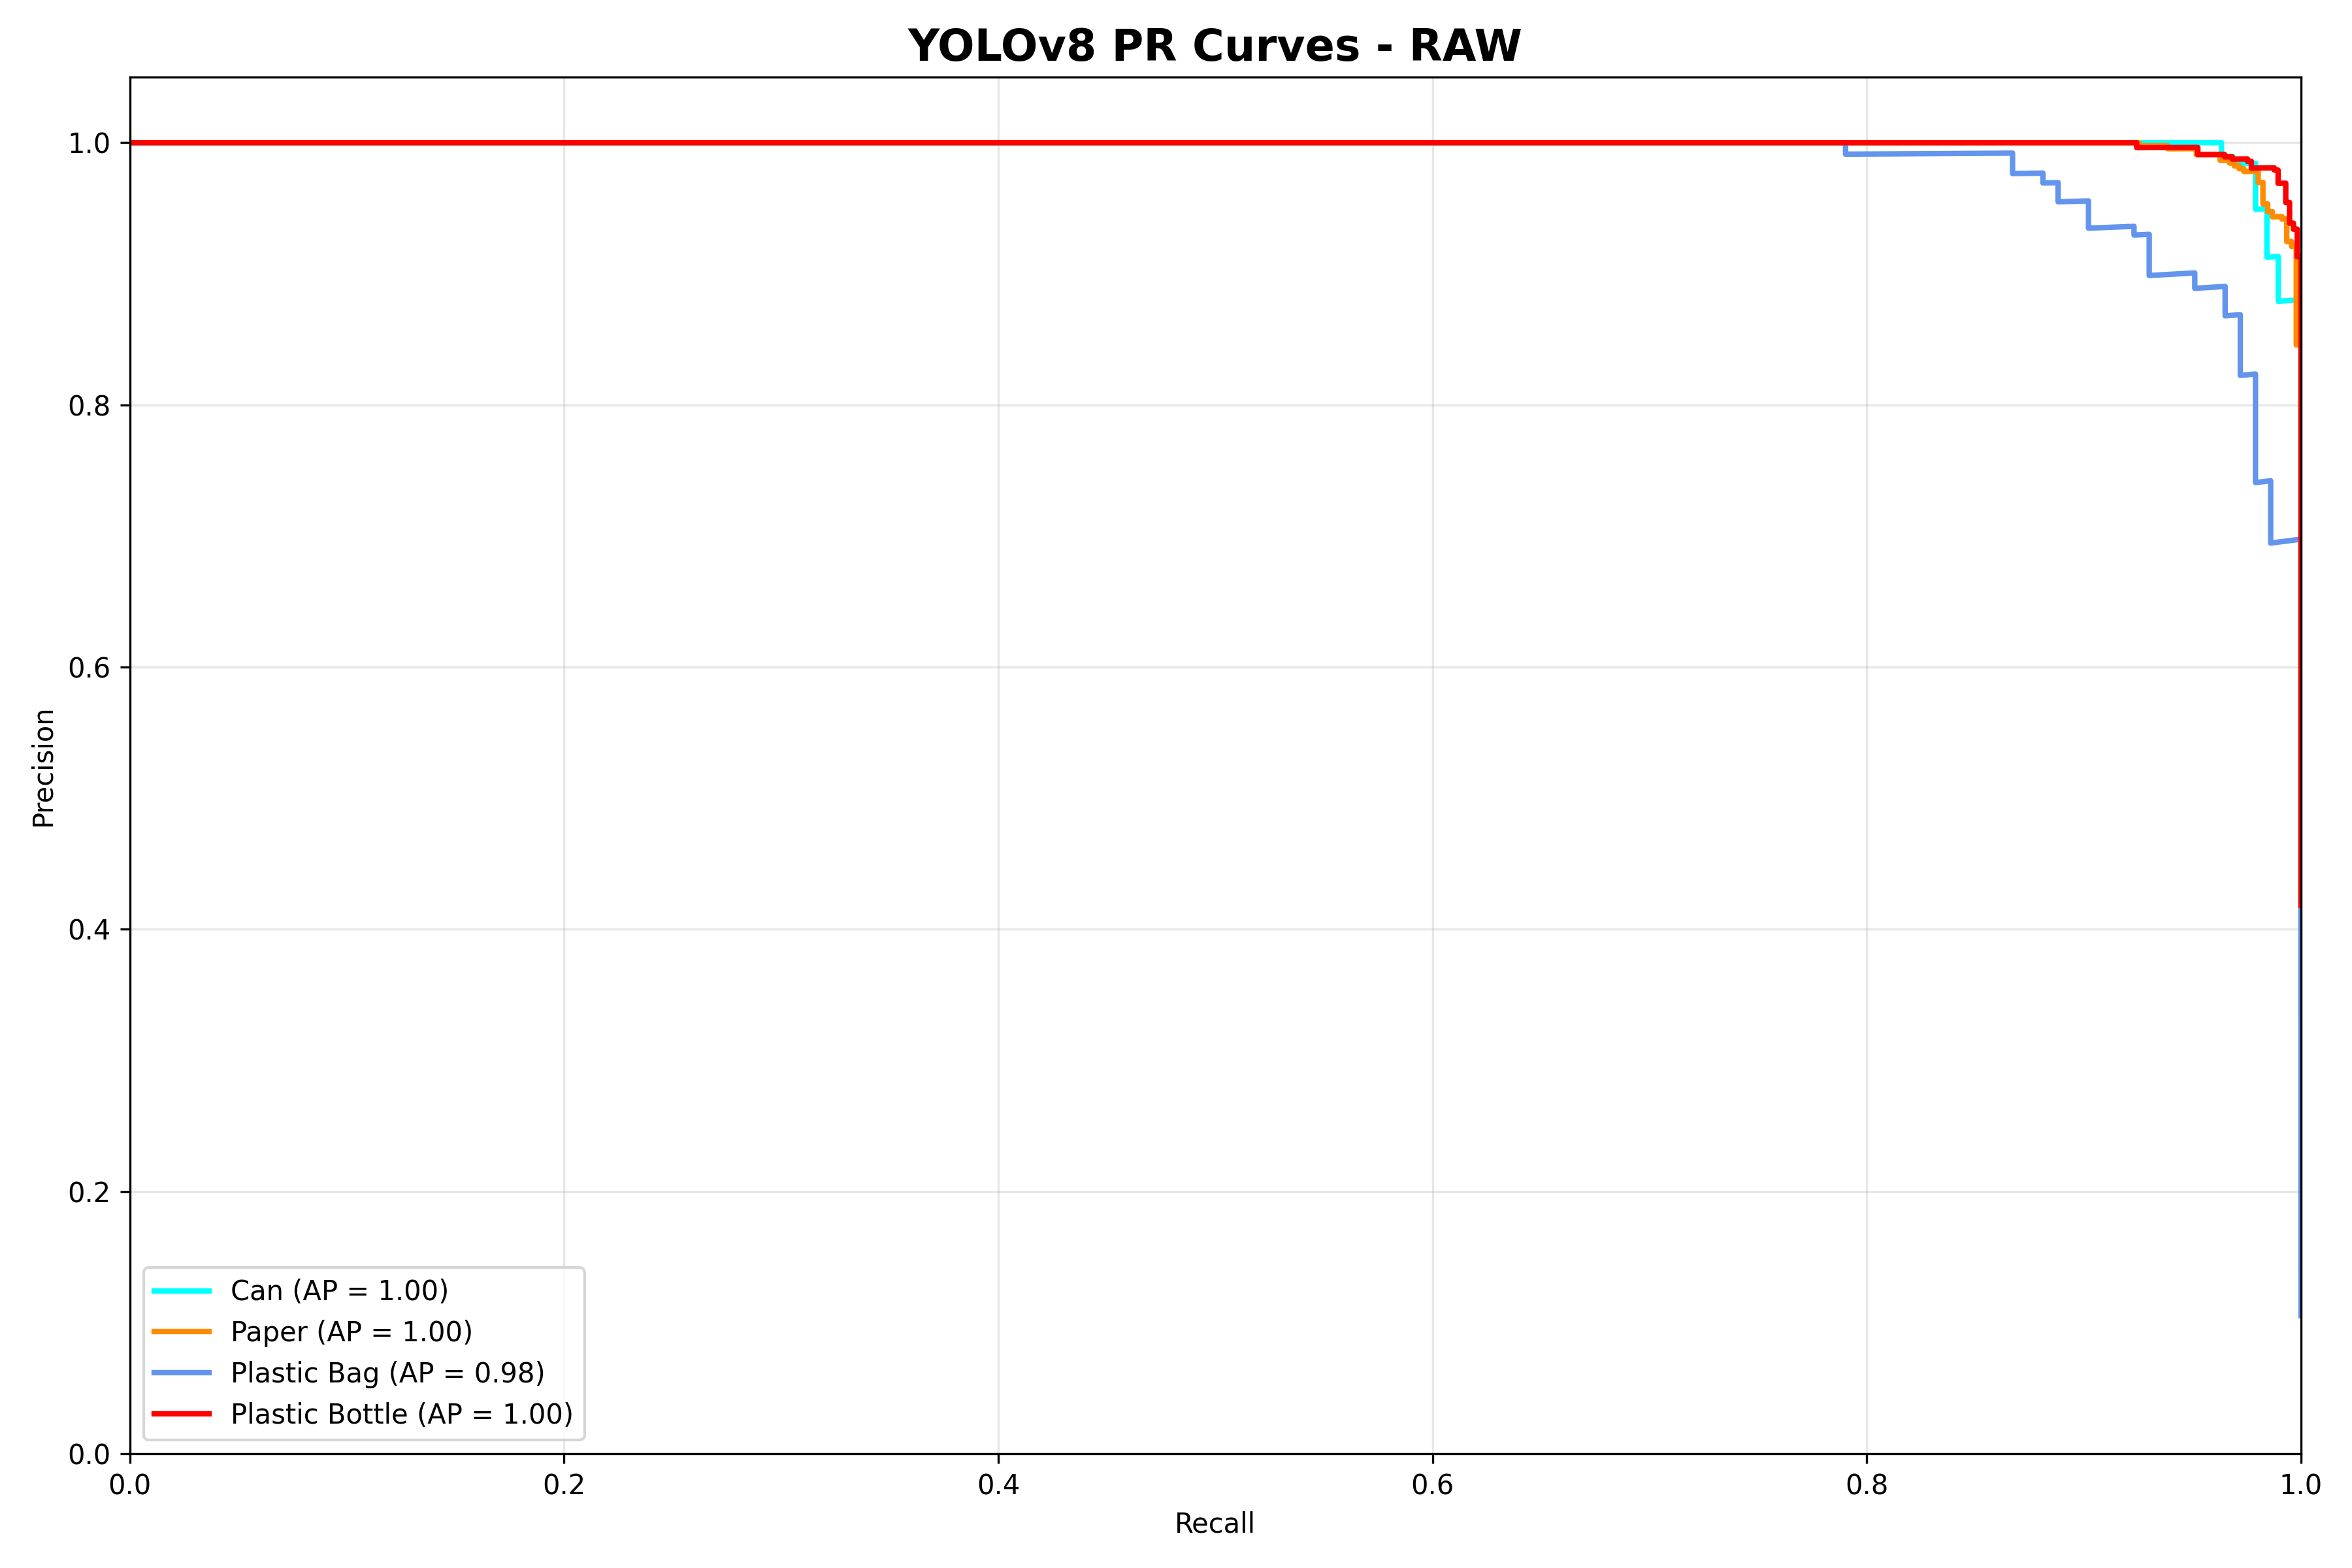

Showing Detailed Confusion Matrix & Per-Class Metrics for raw...


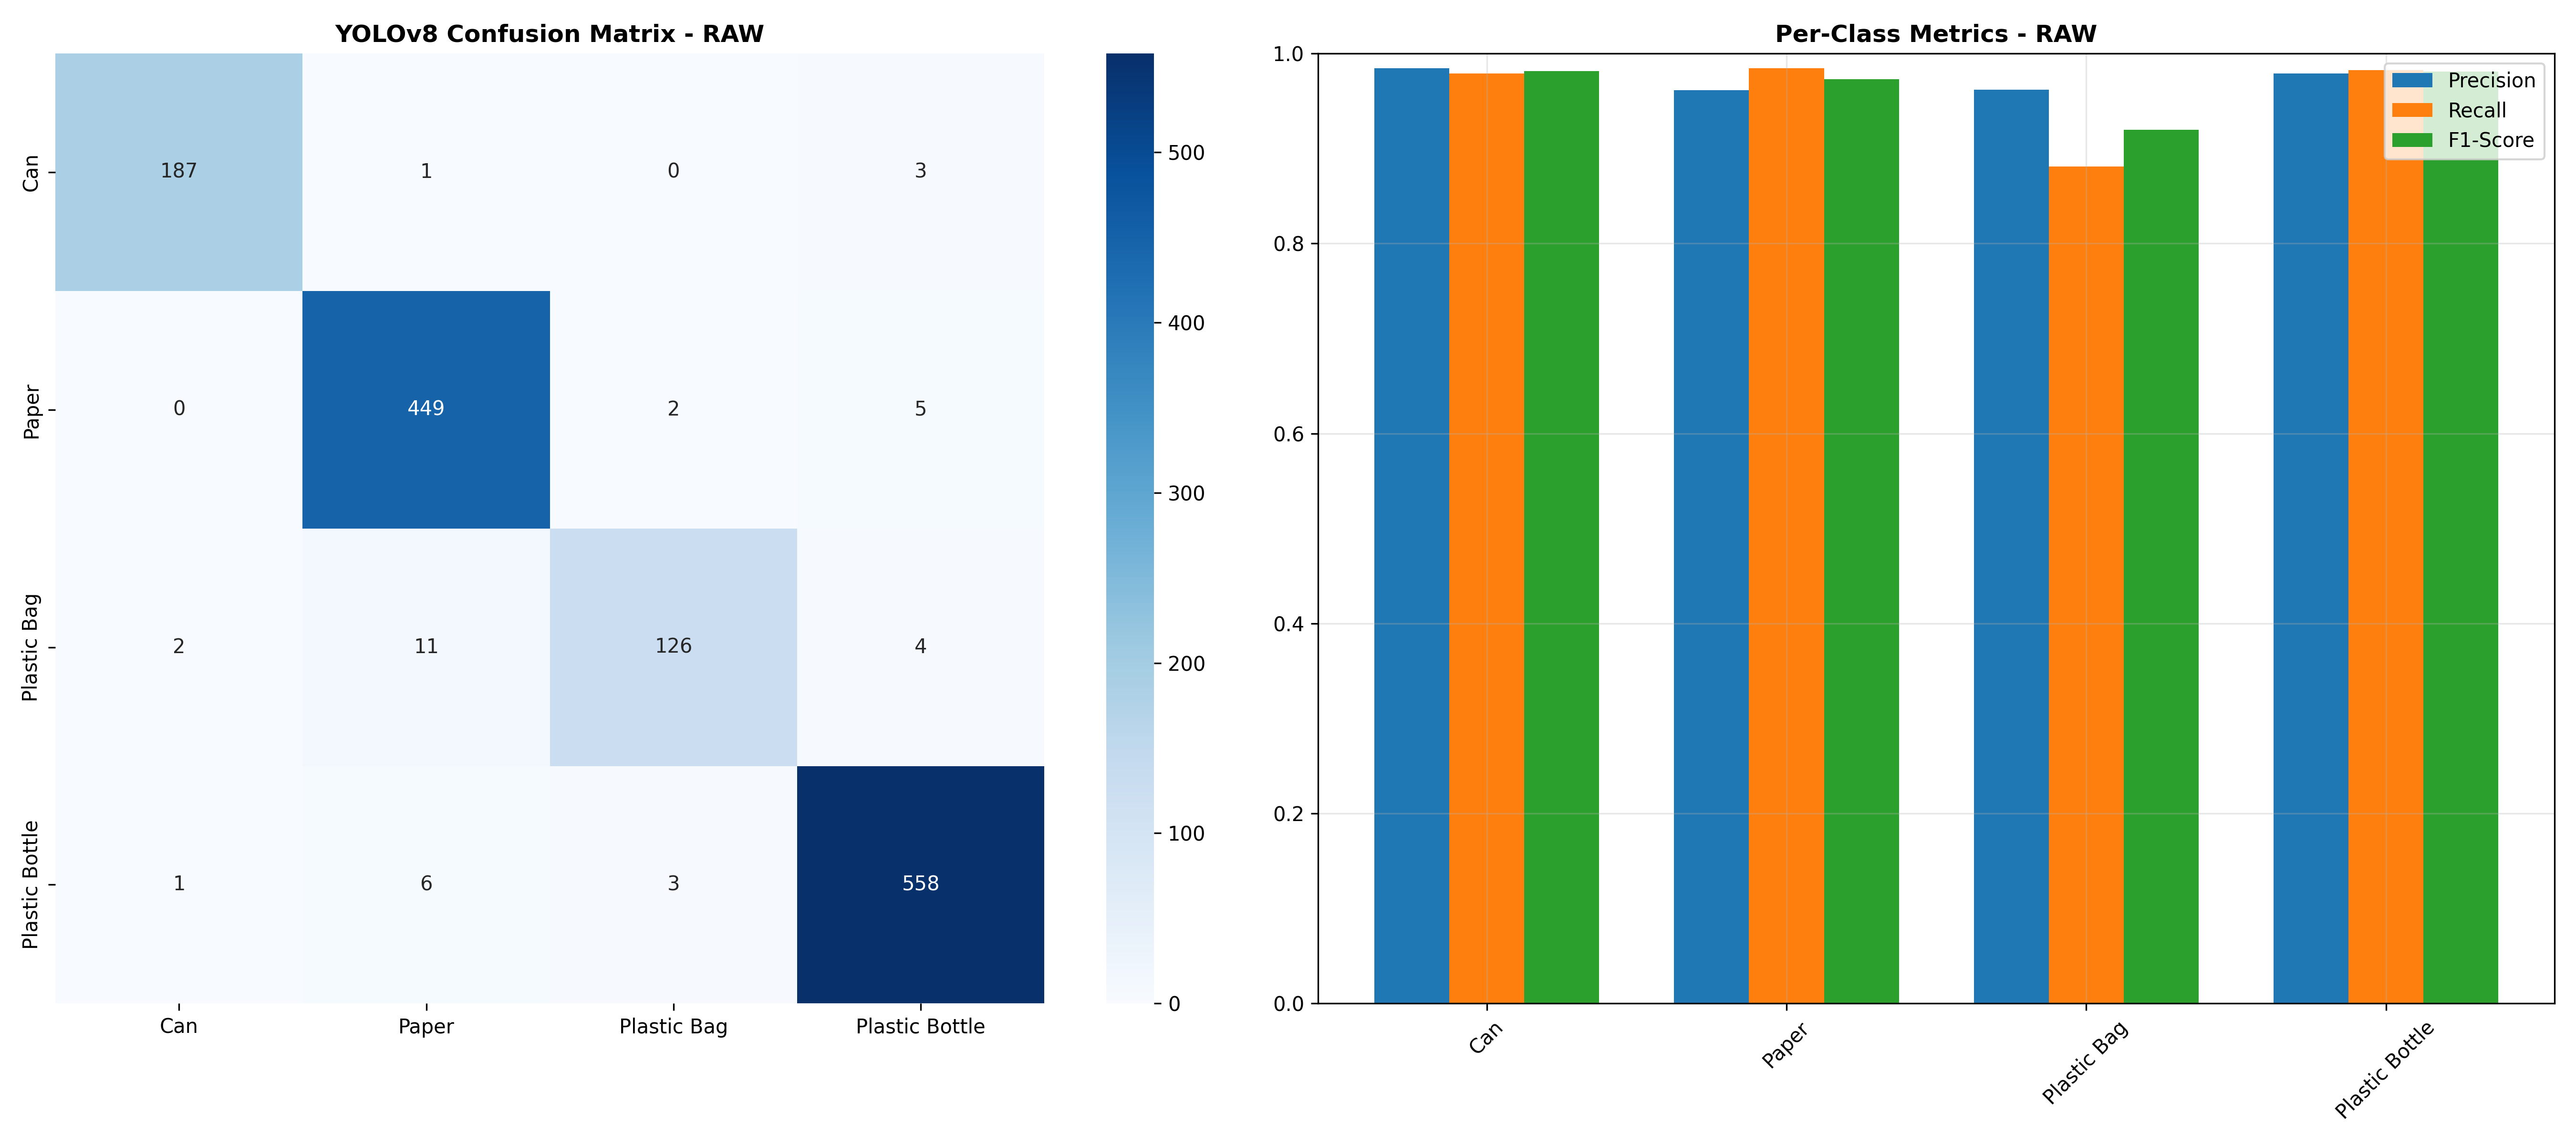

----------------------------------------------------------------------------------------------------


Showing Precision-Recall Curve for unified...


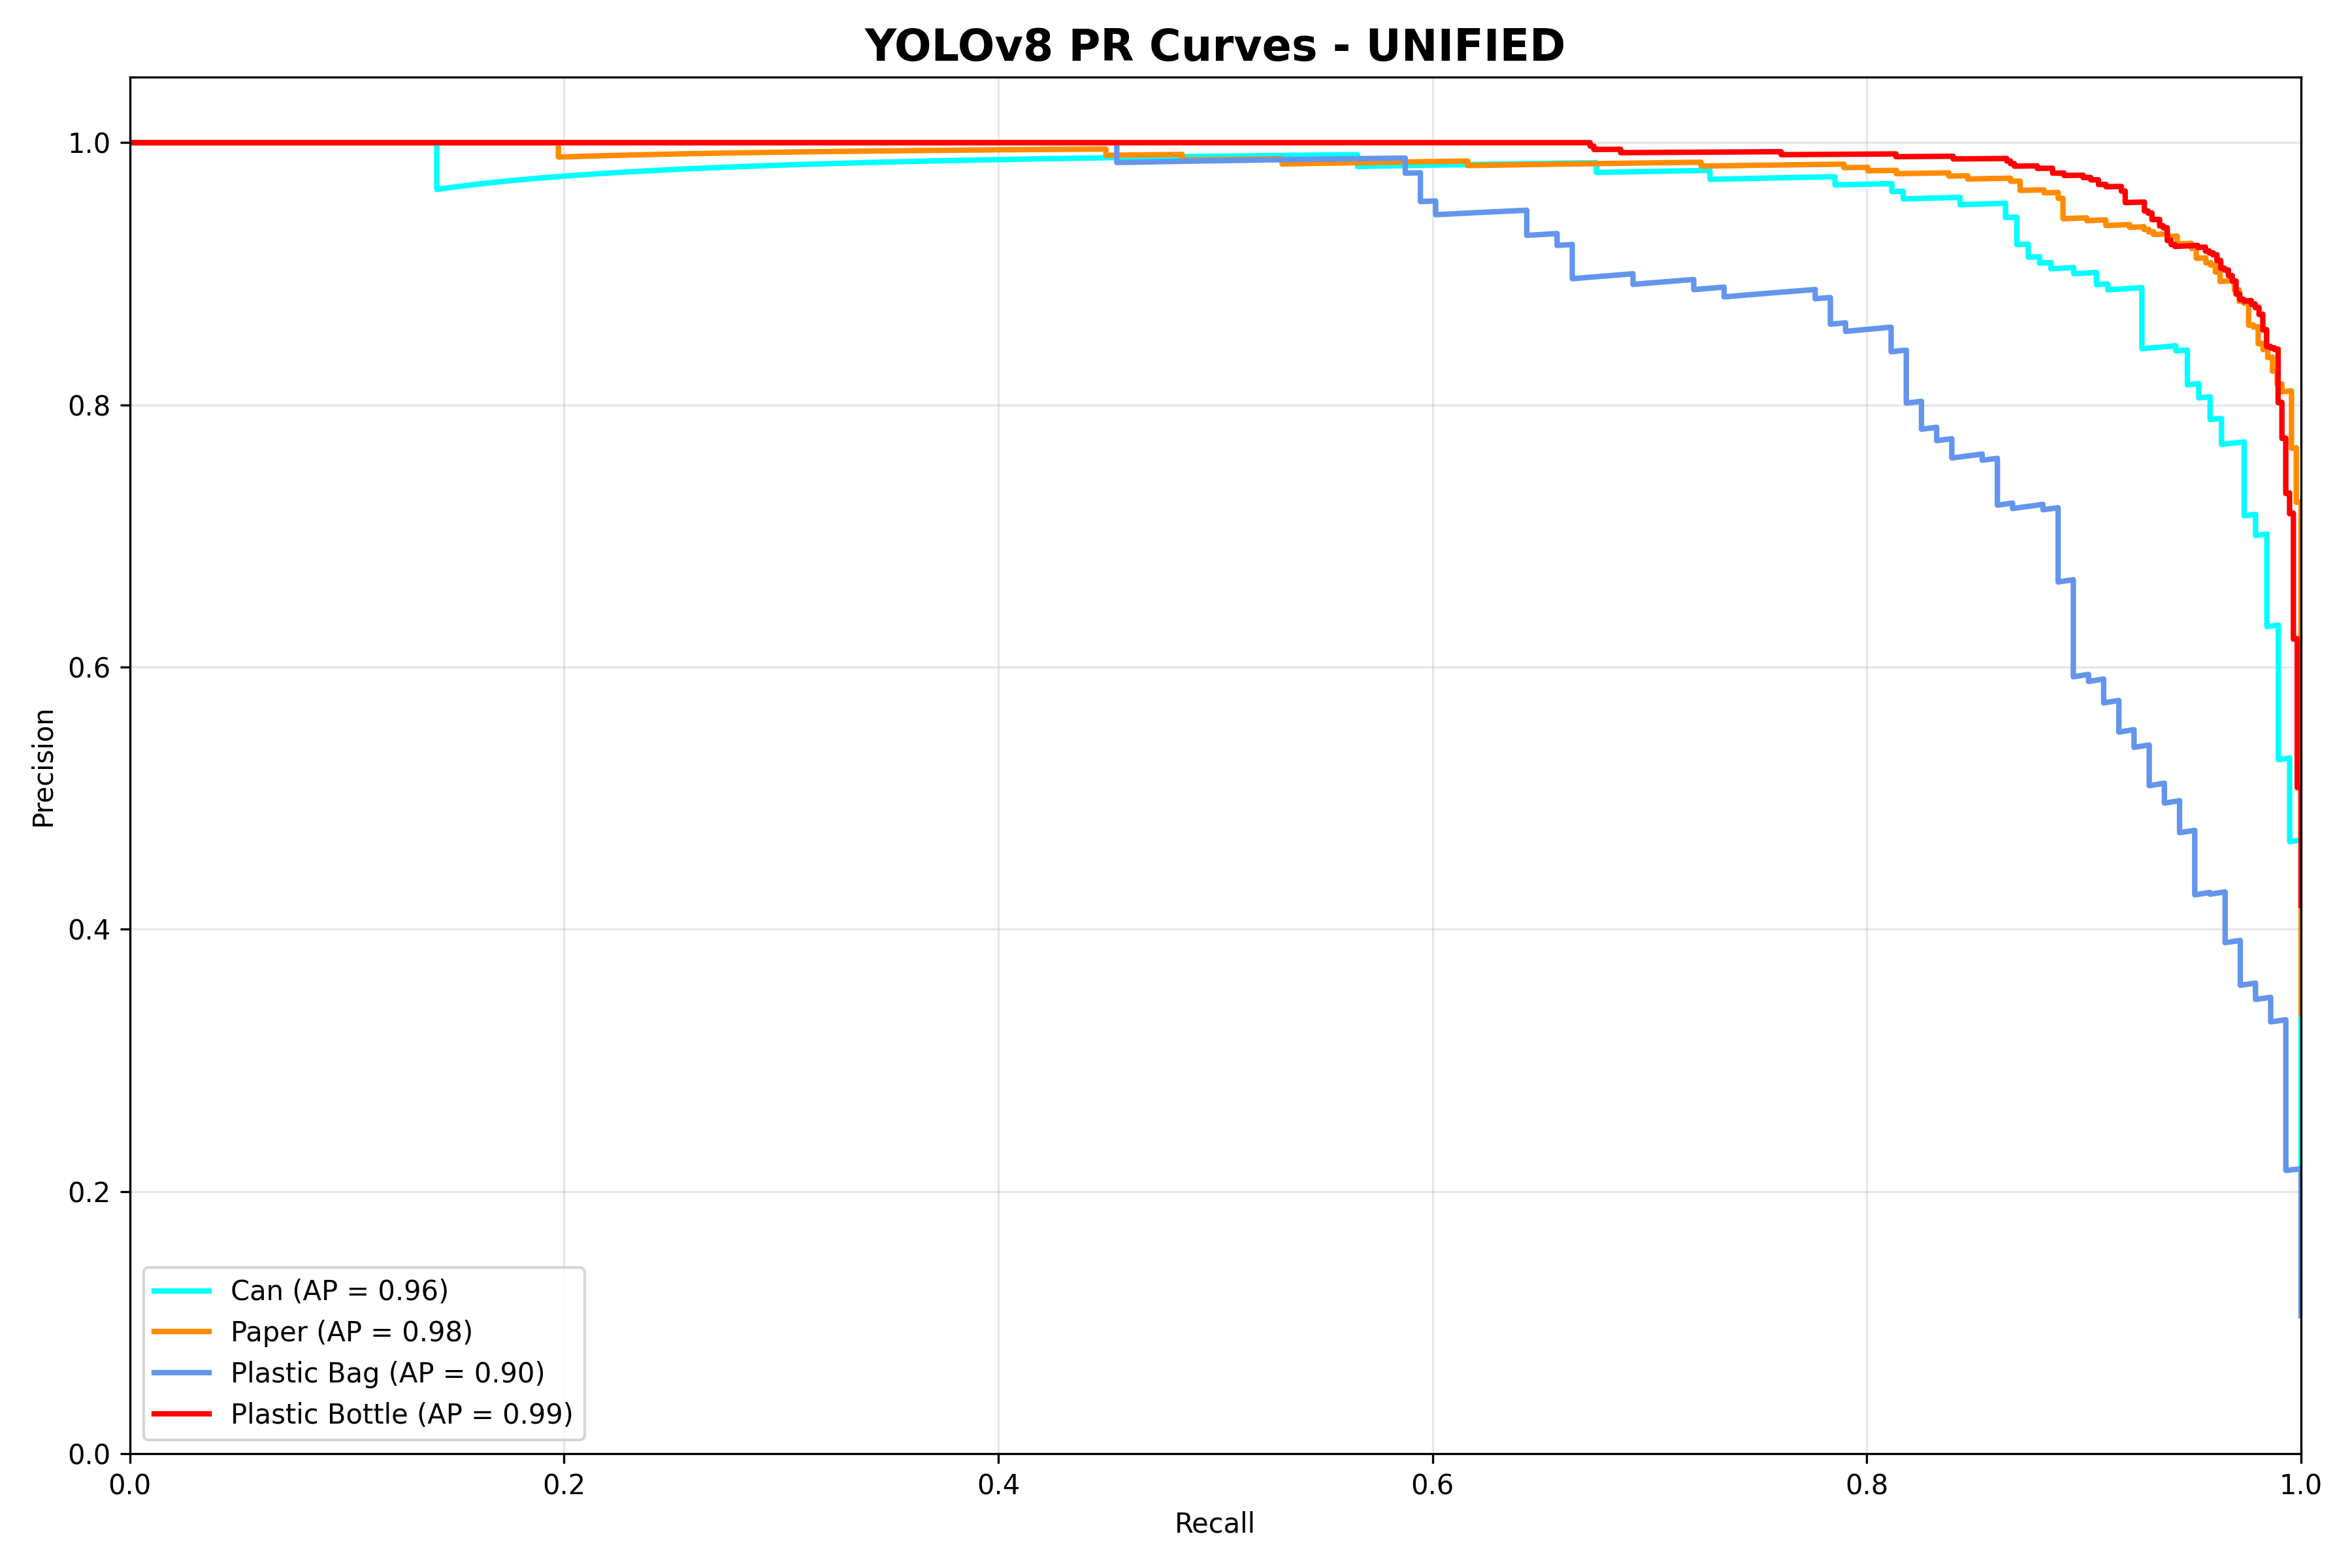

Showing Detailed Confusion Matrix & Per-Class Metrics for unified...


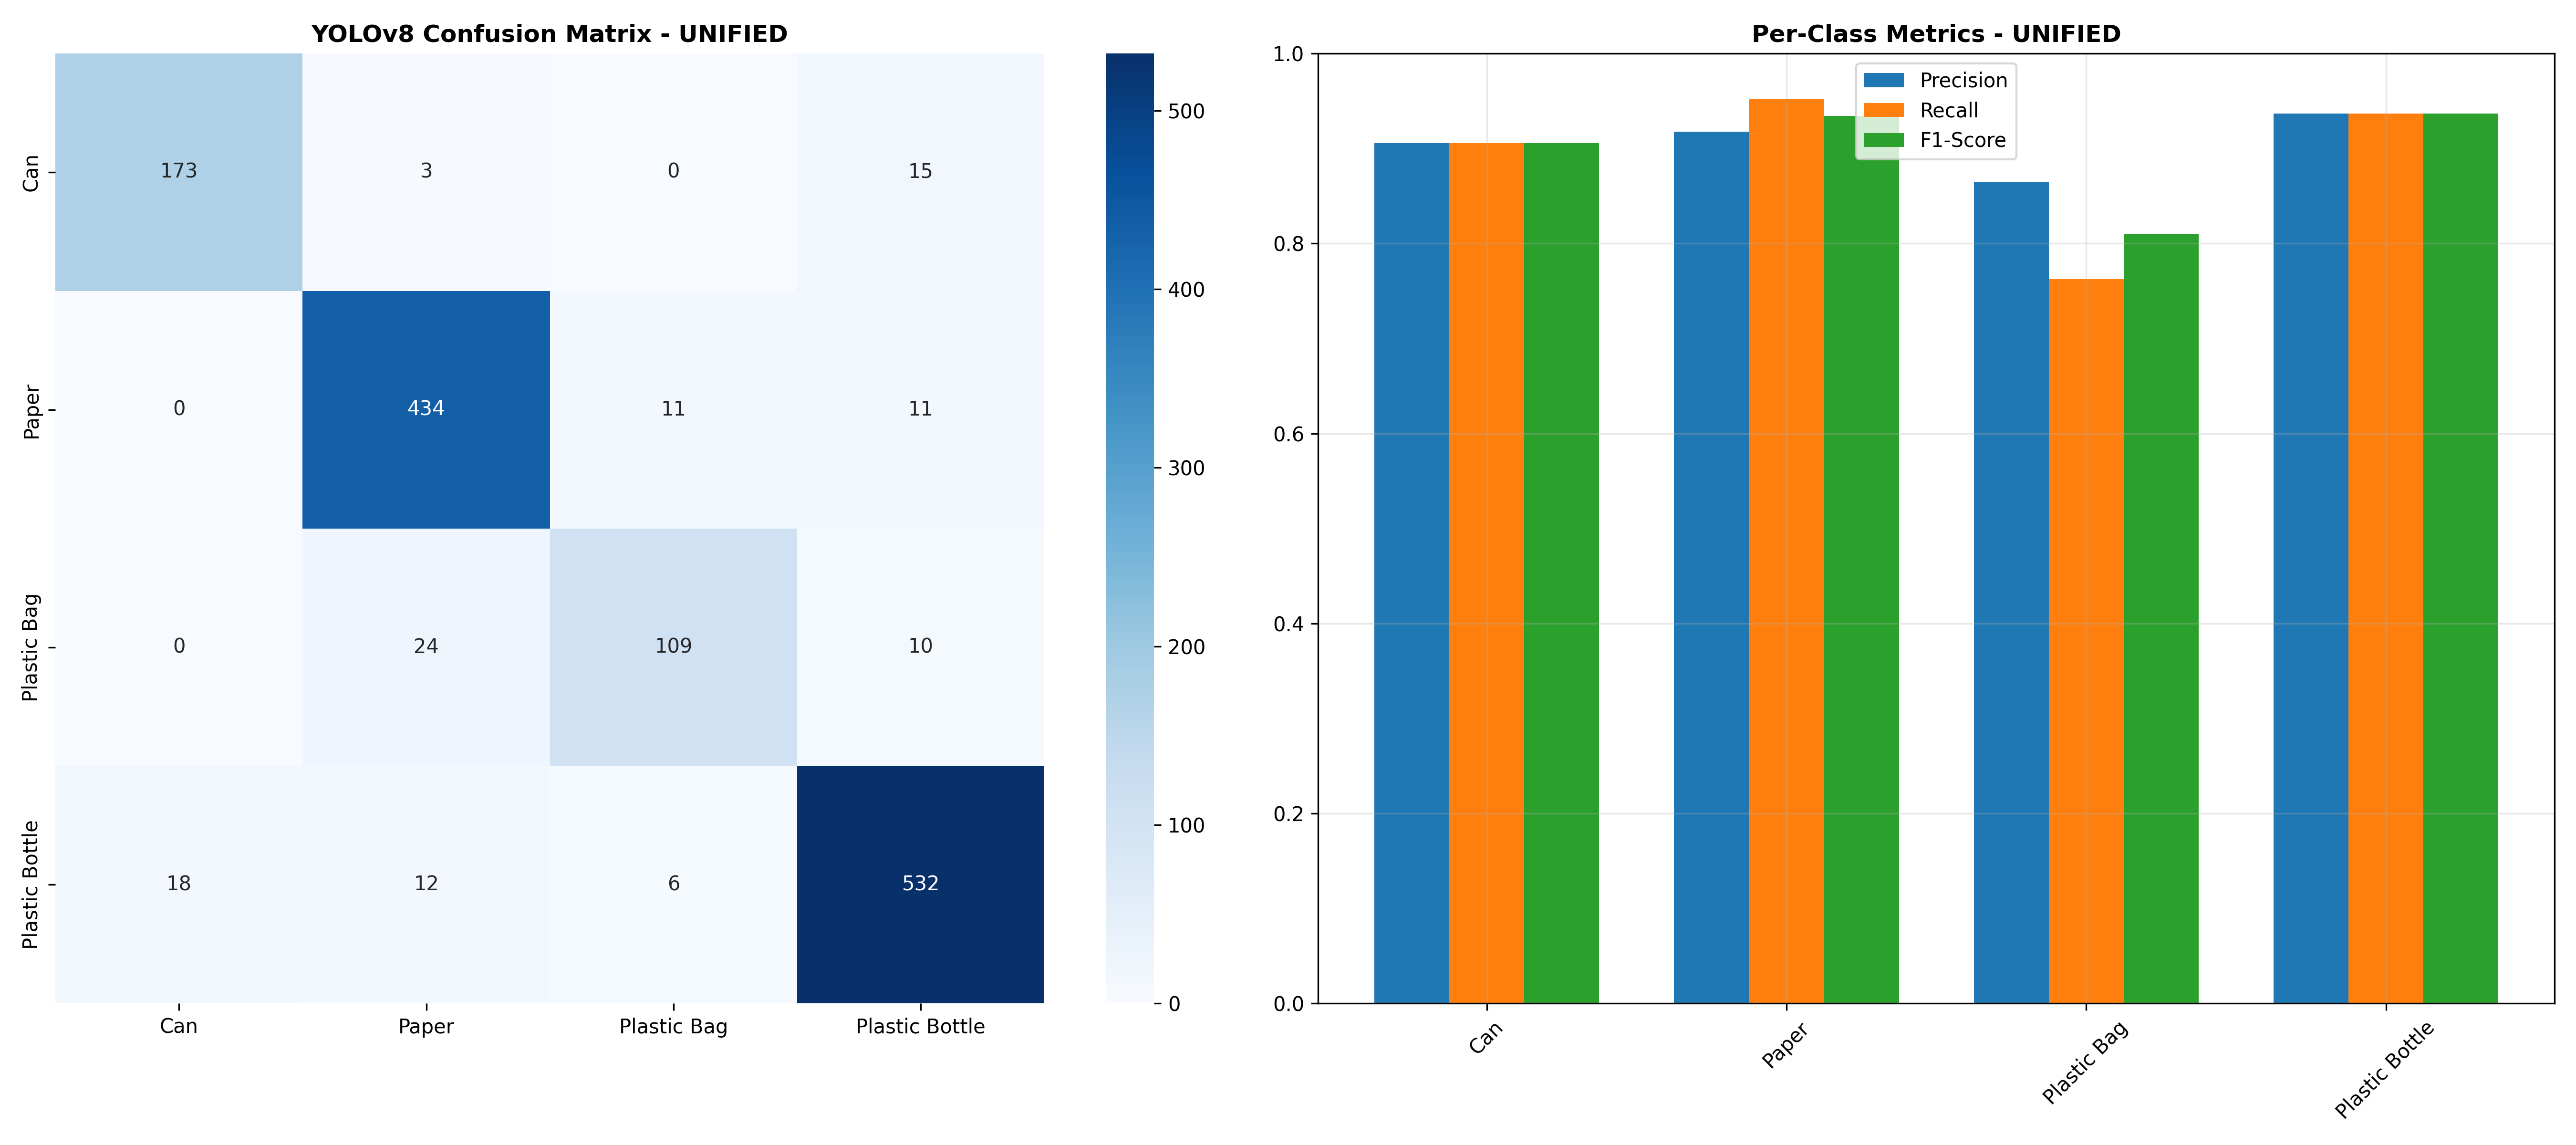

----------------------------------------------------------------------------------------------------


Showing Precision-Recall Curve for customized...


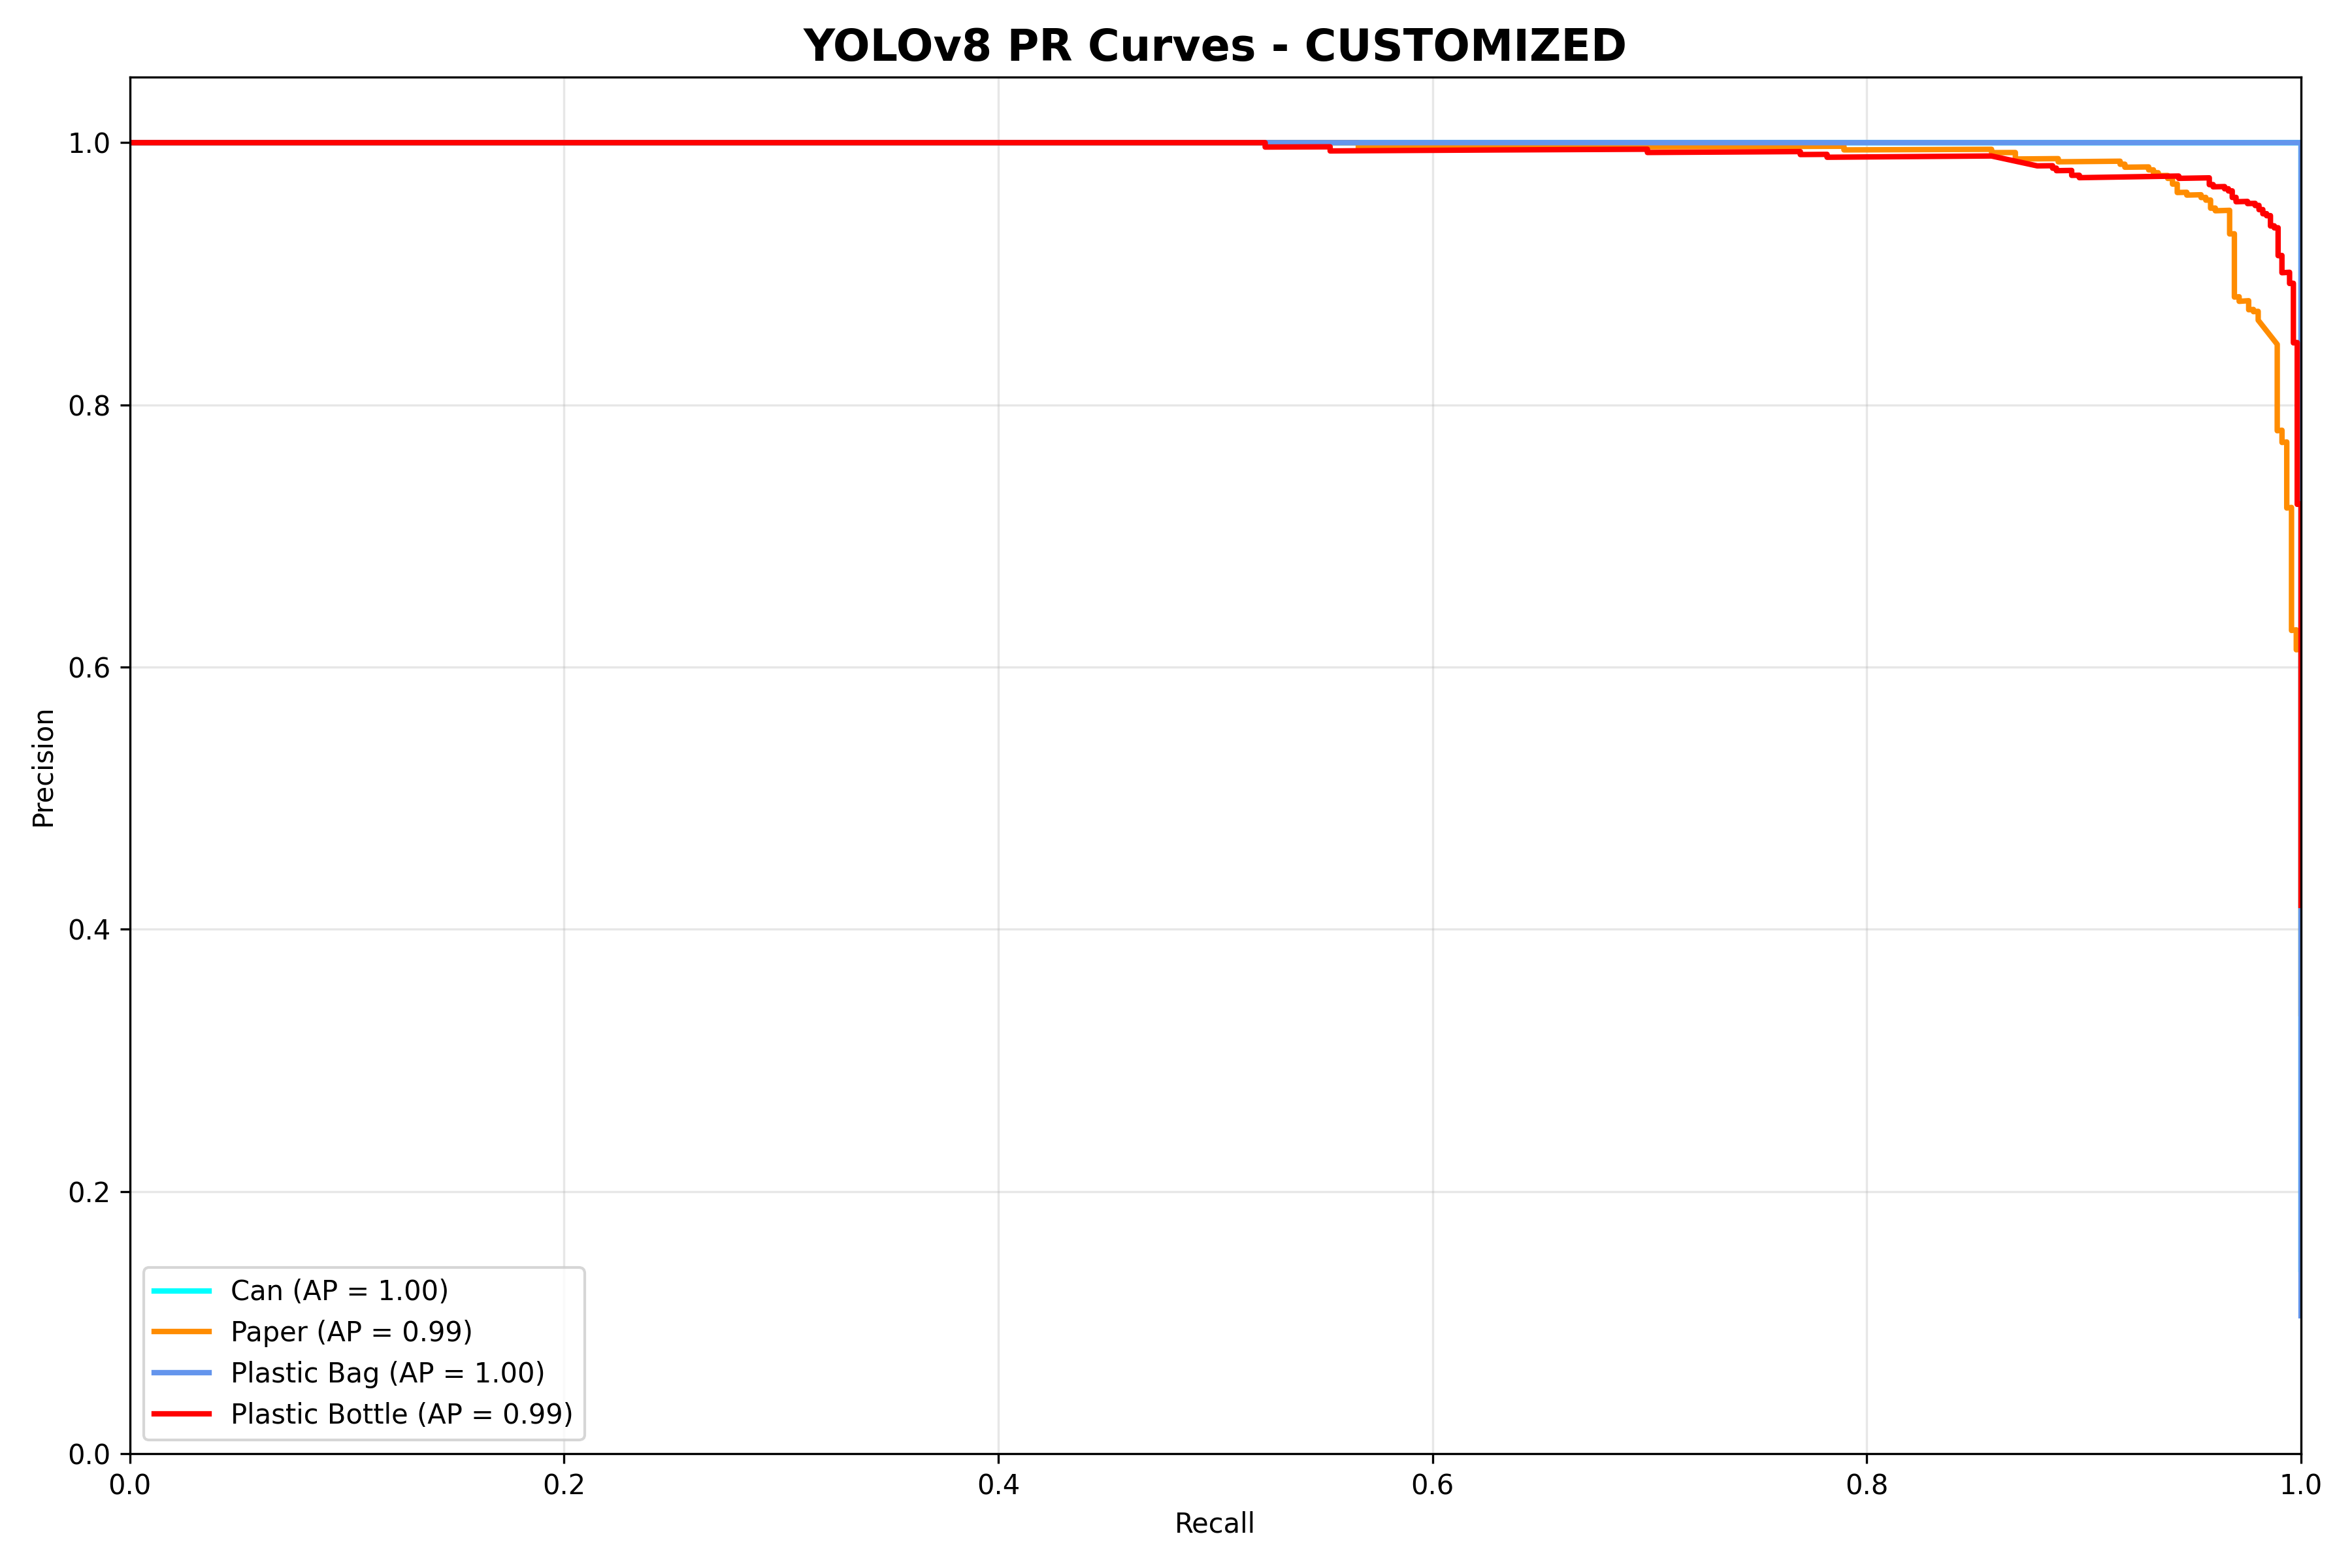

Showing Detailed Confusion Matrix & Per-Class Metrics for customized...


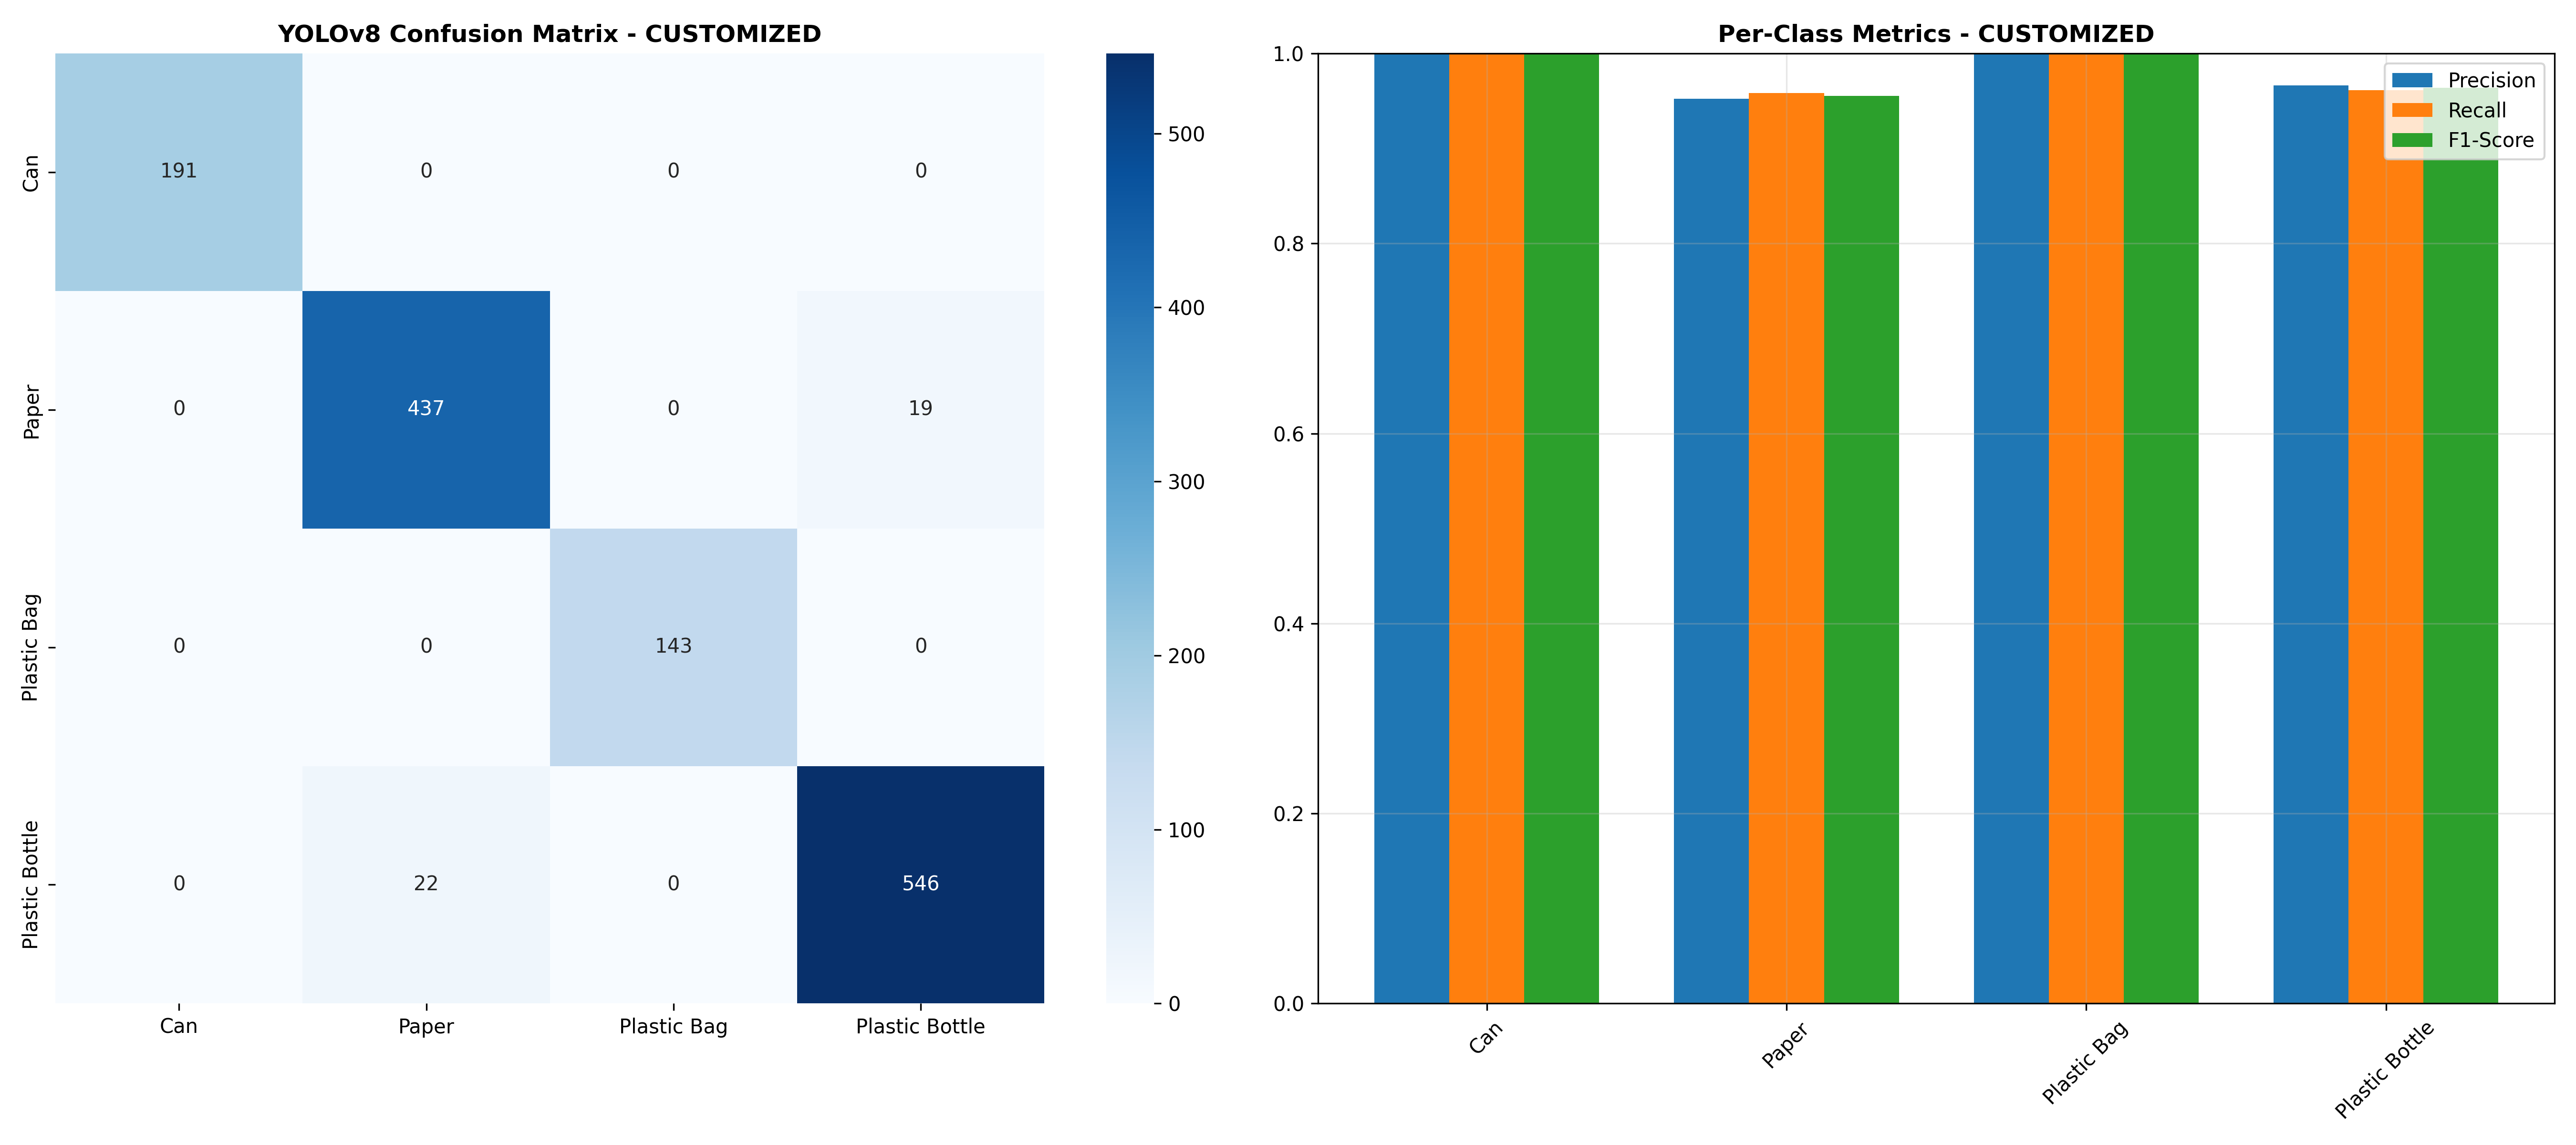

----------------------------------------------------------------------------------------------------


In [16]:
from IPython.display import Image, display, HTML

# Define the versions to display
versions = ['raw', 'unified', 'customized']

for version in versions:
    display(HTML(f"<h2 style='color: #2e76b5; border-bottom: 2px solid #2e76b5;'>Experiment: {version.upper()}</h2>"))
    
    # Define paths for PR Curve and Detailed Confusion Matrix
    pr_path = os.path.join(VIZ_DIR, f"pr_{version}.png")
    cm_path = os.path.join(VIZ_DIR, f"cm_{version}.png")
    
    # Check if files exist before displaying to avoid errors
    if os.path.exists(pr_path):
        print(f"Showing Precision-Recall Curve for {version}...")
        display(Image(filename=pr_path, width=800))
    else:
        print(f"⚠️ PR Curve not found for {version} at {pr_path}")
        
    if os.path.exists(cm_path):
        print(f"Showing Detailed Confusion Matrix & Per-Class Metrics for {version}...")
        display(Image(filename=cm_path, width=1000))
    else:
        print(f"⚠️ Confusion Matrix not found for {version} at {cm_path}")
        
    print("-" * 100)

In [14]:
# 📊 CONSOLIDATE ALL RESULTS WITH COMPARISON VISUALIZATIONS
all_results = []
all_cms = {}
all_aps = {}

# Safely gather results
for result, cm, ap, version in [(result_raw, cm_raw, ap_raw, 'raw'),
                                 (result_unified, cm_unified, ap_unified, 'unified'),
                                 (result_customized, cm_customized, ap_customized, 'customized')]:
    if result is not None:
        all_results.append(result)
        all_cms[version] = cm
        all_aps[version] = ap

if all_results:
    # 1. Save consolidated results to CSV
    consolidated_path = os.path.join(DATA_DIR, "yolov8_all_results.csv")
    df_results = pd.DataFrame(all_results)
    df_results.to_csv(consolidated_path, index=False)
    
    print(f"\n✅ Consolidated results saved to {consolidated_path}")
    print(f"\n📊 FINAL YOLOV8 SUMMARY:")
    print("="*80)
    print(df_results.to_string(index=False))
    
    # 2. Generate comparison visualizations
    print("\n🎨 Generating comparison visualizations...")
    
    # 2.1 Metrics comparison heatmap (Global Performance)
    plt.figure(figsize=(12, 8))
    metrics_for_heatmap = df_results[['Preprocessing', 'Accuracy', 'Precision', 'Recall', 'F1-score']].set_index('Preprocessing')
    sns.heatmap(metrics_for_heatmap.T, annot=True, fmt='.4f', cmap='RdYlGn', 
                cbar_kws={'label': 'Score'}, vmin=0, vmax=1)
    plt.title('YOLOv8 Performance Comparison', fontsize=16, fontweight='bold')
    plt.xlabel('Preprocessing Method')
    plt.ylabel('Metrics')
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, "yolov8_comparison_heatmap.png"), dpi=300)
    plt.show()
    
    # 2.2 Average Precision (AP) comparison by Class
    if all_aps:
        fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(20, 5))
        for i, category in enumerate(CATEGORIES):
            versions = list(all_aps.keys())
            ap_values = [all_aps[v][i] for v in versions if v in all_aps]
            
            bars = axes[i].bar(versions, ap_values, color=['skyblue', 'lightcoral', 'lightgreen'])
            axes[i].set_title(f'{category} AP', fontweight='bold')
            axes[i].set_ylim(0, 1)
            
            for bar, val in zip(bars, ap_values):
                axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                           f'{val:.3f}', ha='center', fontweight='bold')
        
        plt.suptitle('YOLOv8 Class-level AP Comparison', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(VIZ_DIR, "yolov8_ap_comparison.png"), dpi=300)
        plt.show()
    
    # 2.3 Inference speed comparison (Real-time feasibility)
    if 'Inference_Time_Per_Sample' in df_results.columns:
        plt.figure(figsize=(10, 6))
        bars = plt.bar(df_results['Preprocessing'], df_results['Inference_Time_Per_Sample'] * 1000, 
                      color=['skyblue', 'lightcoral', 'lightgreen'])
        plt.title('YOLOv8 Inference Speed (ms per Sample)', fontsize=16, fontweight='bold')
        
        for bar, value in zip(bars, df_results['Inference_Time_Per_Sample'] * 1000):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{value:.2f}ms', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(os.path.join(VIZ_DIR, "yolov8_inference_speed.png"), dpi=300)
        plt.show()
    
    # Find best result
    best_result = df_results.iloc[df_results['Accuracy'].idxmax()]
    print(f"\n🏆 BEST YOLOV8: {best_result['Preprocessing']} (Accuracy: {best_result['Accuracy']:.4f})")
    print(f"\n📁 All visualizations saved to: {VIZ_DIR}")
else:
    print("❌ No results to consolidate")

print("\n🏁 YOLOv8 experiments with visualization completed!")


✅ Consolidated results saved to ..\data\yolov8_all_results.csv

📊 FINAL YOLOV8 SUMMARY:
     Model Preprocessing  Accuracy  Precision   Recall  F1-score  Training_Time  Inference_Time_Per_Sample
YOLOv8-cls           raw  0.972018   0.971612 0.956805  0.963729     271.438478                   0.010057
YOLOv8-cls       unified  0.918999   0.906251 0.889093  0.896781     297.509819                   0.013938
YOLOv8-cls    customized  0.969809   0.979610 0.979900  0.979751     308.962864                   0.011947

🎨 Generating comparison visualizations...


<Figure size 1200x800 with 2 Axes>

<Figure size 2000x500 with 4 Axes>

<Figure size 1000x600 with 1 Axes>


🏆 BEST YOLOV8: raw (Accuracy: 0.9720)

📁 All visualizations saved to: .\visualizations\yolov8

🏁 YOLOv8 experiments with visualization completed!
